In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rawppgsignals = pd.read_csv('waveform_u1.csv')["signal"]
ppgsignals = -rawppgsignals

# Resampling

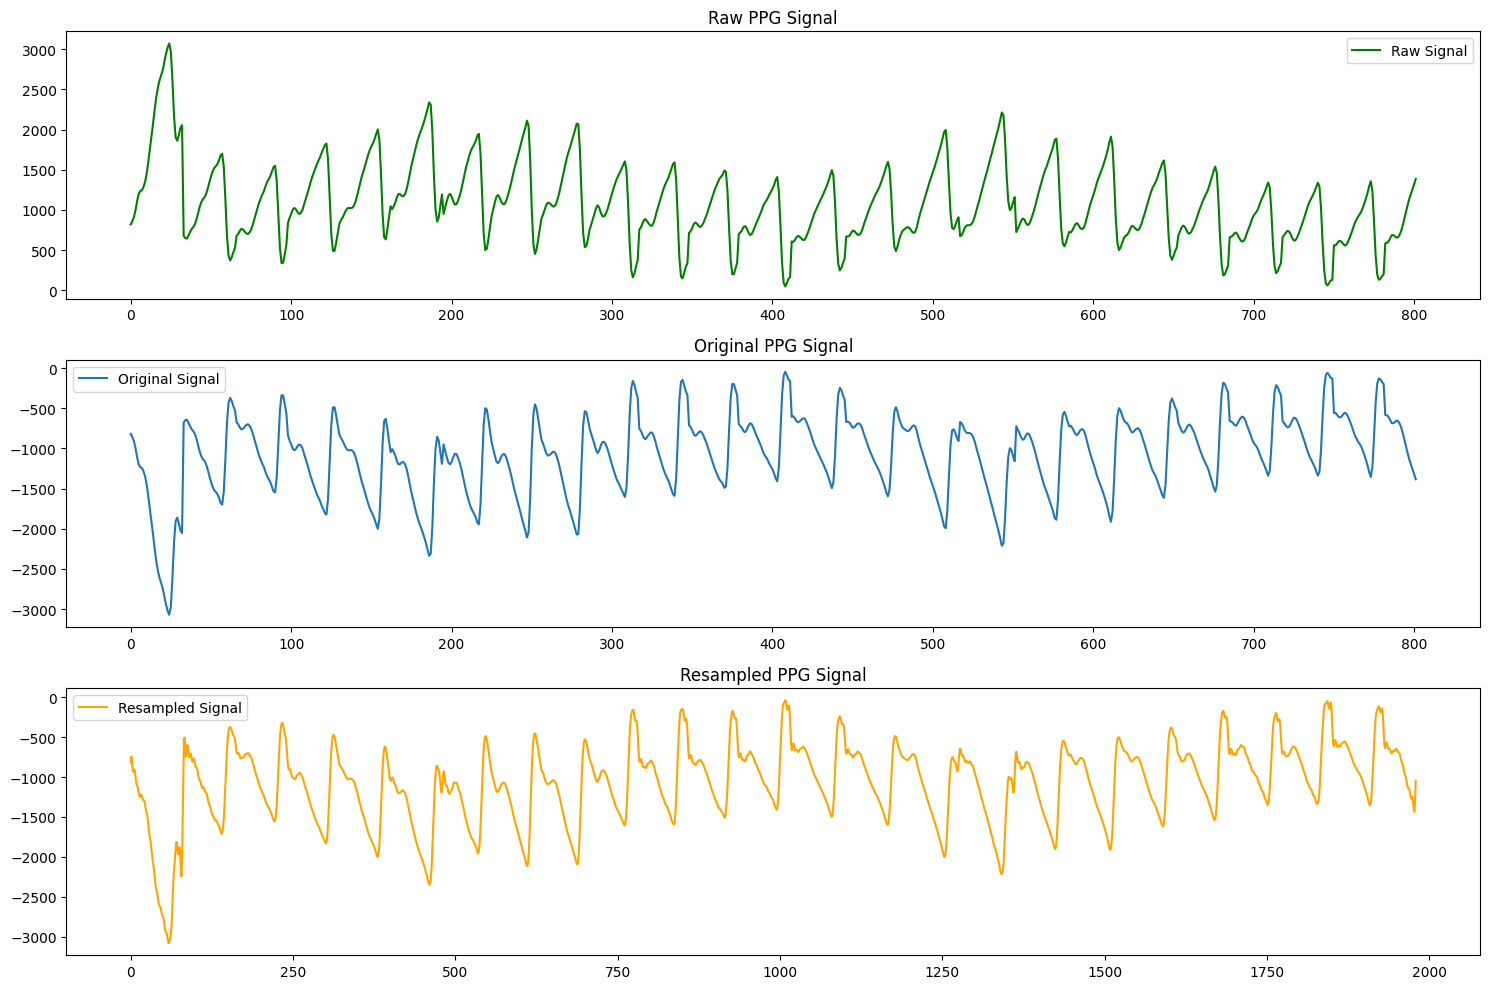

In [3]:
from scipy.signal import resample

OLD_FREQUENCY = 40.5
NEW_FREQUENCY = 100

ppgsignals_resampled = resample(ppgsignals, int(len(ppgsignals) * NEW_FREQUENCY / OLD_FREQUENCY))

fig, axes = plt.subplots(3, 1, figsize=(15, 10))
axes[0].plot(rawppgsignals, label='Raw Signal', color='green')
axes[0].set_title('Raw PPG Signal')
axes[0].legend()

axes[1].plot(ppgsignals, label='Original Signal')
axes[1].set_title('Original PPG Signal')
axes[1].legend()

axes[2].plot(ppgsignals_resampled, label='Resampled Signal', color='orange')
axes[2].set_title('Resampled PPG Signal')
axes[2].legend()
plt.tight_layout()
plt.show()

# Filter + Spline

In [4]:
from filtering_spline import detect_valleys_ppg, spline_baseline_removal_v2

valleys, peaks, filt = detect_valleys_ppg(ppgsignals_resampled, fs=NEW_FREQUENCY, low=0.5, high=6.0)

detrended, baseline, segments = spline_baseline_removal_v2(filt, valleys)

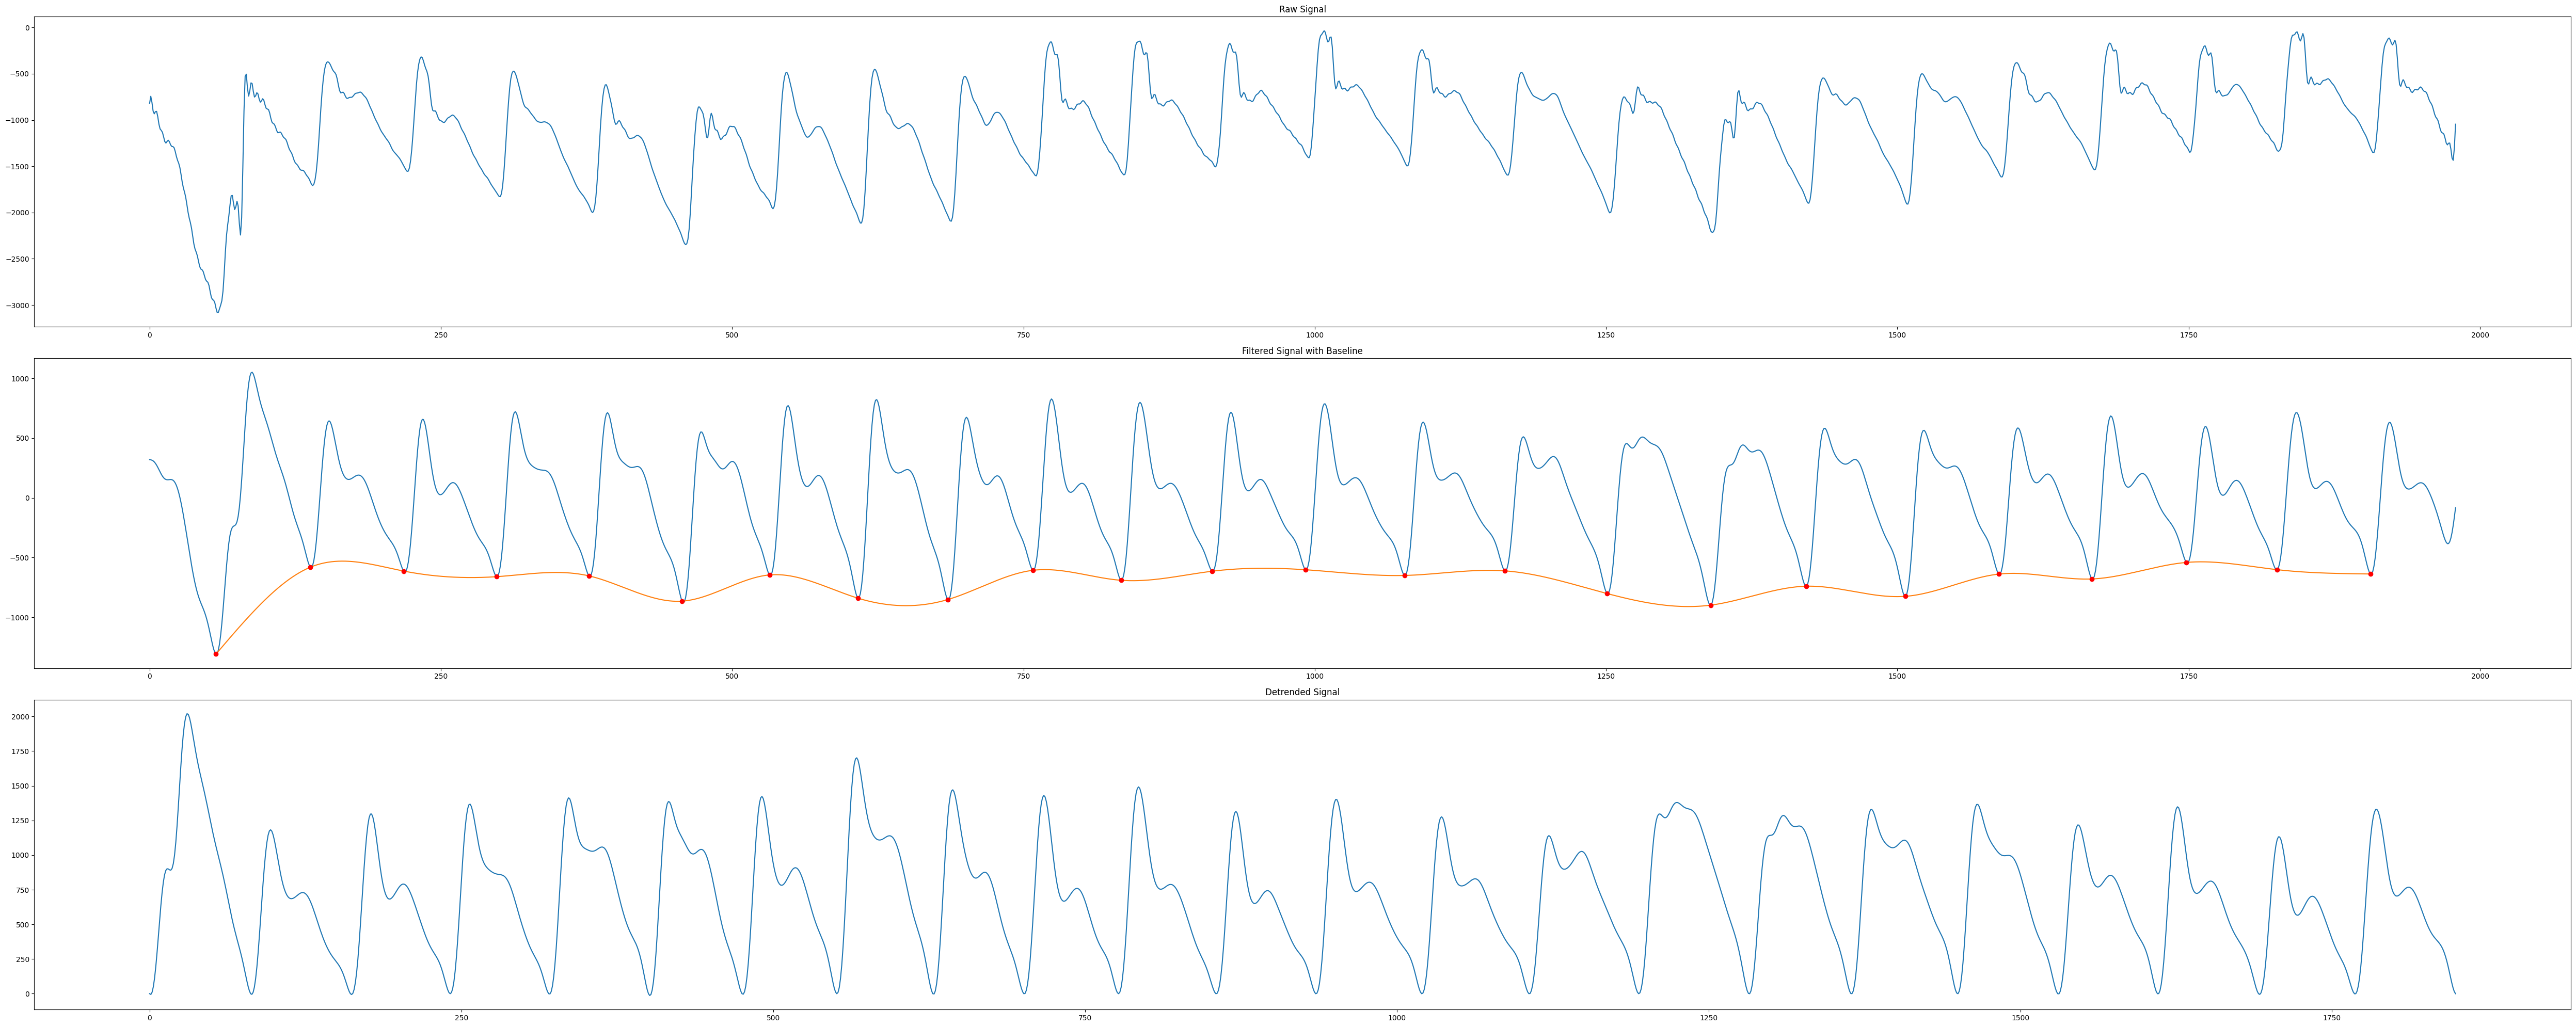

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(50, 20))

axes[0].plot(ppgsignals_resampled)
axes[0].set_title('Raw Signal')

axes[1].plot(filt)
axes[1].plot(baseline)
axes[1].plot(valleys, filt[valleys], 'ro', label='Valleys')
axes[1].set_title('Filtered Signal with Baseline')

axes[2].plot(detrended)
axes[2].set_title('Detrended Signal')

plt.tight_layout()
plt.show()



# Take 15 segments + Normalise

In [6]:
from sklearn.preprocessing import MinMaxScaler

NUM_SEGMENTS = 15
last_15 = segments[-NUM_SEGMENTS:]

lengths = [len(seg) for seg in last_15]
print("Lengths of the last 15 segments:", lengths)

concat_last_15 = np.concatenate(last_15)
print("Length of concatenated last 15 segments:", len(concat_last_15))

scaler = MinMaxScaler(feature_range=(0, 1))
norm_concat_last_15 = scaler.fit_transform(concat_last_15.reshape(-1, 1)).flatten()

normalized_segments = []
start = 0
for length in lengths:
    end = start + length
    normalized_segments.append(norm_concat_last_15[start:end])
    start = end
print("Lengths of normalized segments:", [len(seg) for seg in normalized_segments])

Lengths of the last 15 segments: [74, 77, 79, 81, 86, 87, 89, 90, 83, 86, 81, 81, 82, 79, 81]
Length of concatenated last 15 segments: 1236
Lengths of normalized segments: [74, 77, 79, 81, 86, 87, 89, 90, 83, 86, 81, 81, 82, 79, 81]


In [7]:
SEG_LEN = 100

padded_segments = []
mask_segments   = []

for seg in normalized_segments:
    seg = np.asarray(seg)[:SEG_LEN]          # truncate if longer than 100
    real_len  = len(seg)
    pad_width = SEG_LEN - real_len

    padded_segments.append(np.pad(seg, (0, pad_width), mode='constant', constant_values=0))
    mask_segments.append(np.concatenate([np.ones(real_len), np.zeros(pad_width)]))

signal_1500 = np.concatenate(padded_segments)   # (1500,)
mask_1500   = np.concatenate(mask_segments)      # (1500,)

print(f"Signal shape: {signal_1500.shape}")
print(f"Mask shape  : {mask_1500.shape}")

Signal shape: (1500,)
Mask shape  : (1500,)


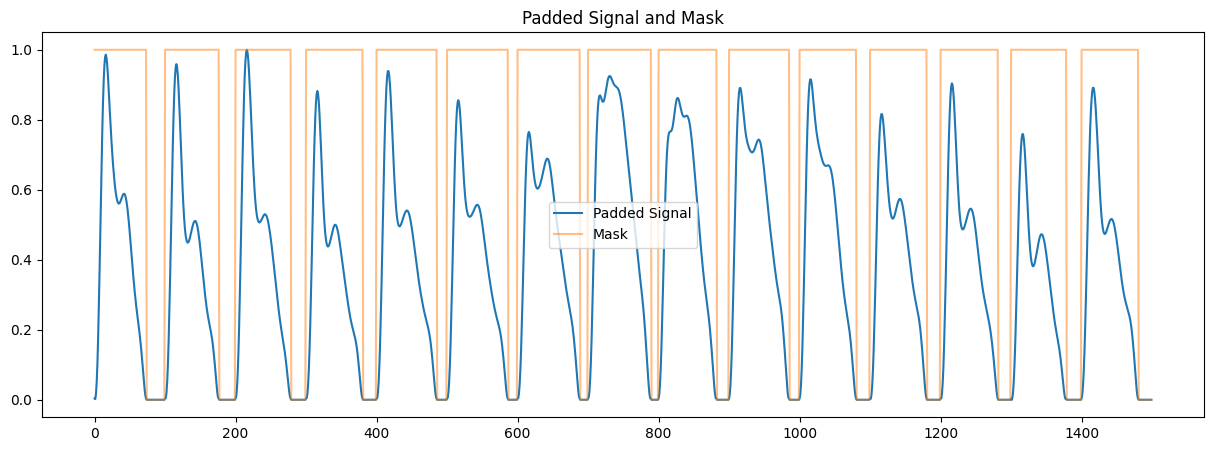

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(signal_1500, label='Padded Signal')
plt.plot(mask_1500, label='Mask', alpha=0.5)
plt.title('Padded Signal and Mask')
plt.legend()
plt.show()

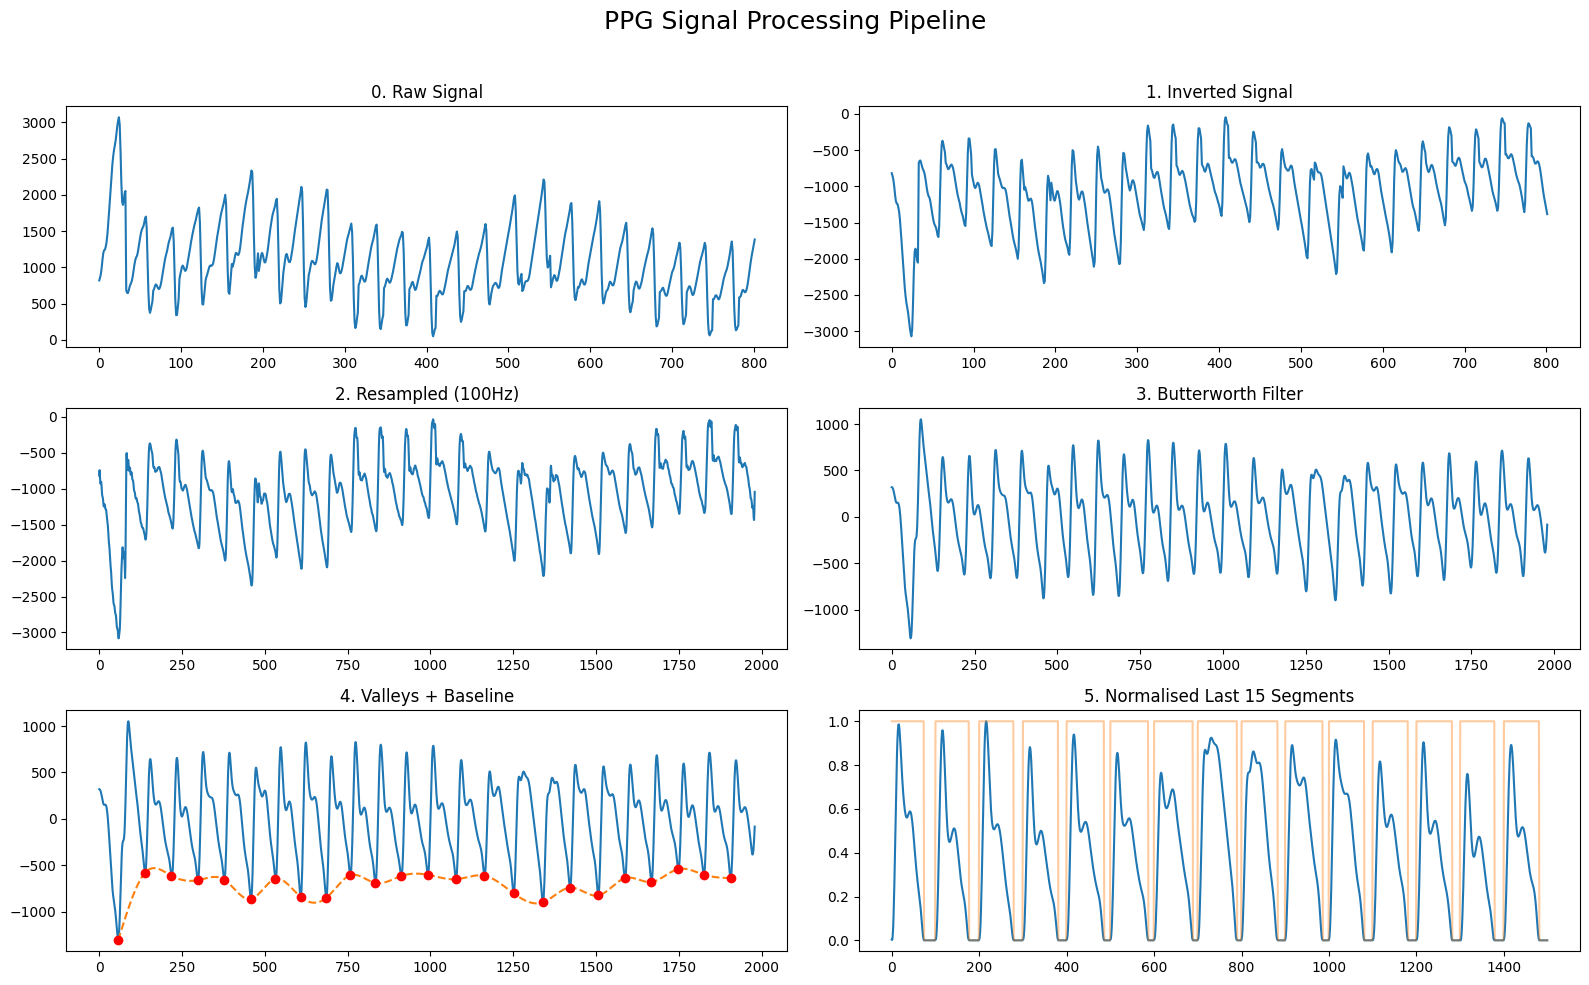

In [9]:
import matplotlib.pyplot as plt

step_titles = [
    "0. Raw Signal",
    "1. Inverted Signal",
    "2. Resampled (100Hz)",
    "3. Butterworth Filter",
    "4. Valleys + Baseline",
    "5. Normalised Last 15 Segments"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

# --- Plot each stage ---
axes[0].plot(rawppgsignals)
axes[0].set_title(step_titles[0])

axes[1].plot(ppgsignals)
axes[1].set_title(step_titles[1])

axes[2].plot(ppgsignals_resampled)
axes[2].set_title(step_titles[2])

axes[3].plot(filt)
axes[3].set_title(step_titles[3])

axes[4].plot(filt)
axes[4].plot(baseline, linestyle='--')
axes[4].plot(valleys, filt[valleys], 'ro')
axes[4].set_title(step_titles[4])

axes[5].plot(signal_1500)
axes[5].plot(mask_1500, alpha=0.4)
axes[5].set_title(step_titles[5])

# # --- Clean up axes ---
# for ax in axes:
#     ax.set_xticks([])
#     ax.set_yticks([])

# # --- Add arrows between plots ---
# def connect(ax_from, ax_to):
#     ax_from.annotate(
#         "",
#         xy=(0.5, -0.15), xycoords='axes fraction',
#         xytext=(0.5, 1.15), textcoords=ax_to.transAxes,
#         arrowprops=dict(arrowstyle="->", linewidth=1.5)
#     )

# # Row-wise connections
# connect(axes[0], axes[2])
# connect(axes[2], axes[4])

# connect(axes[1], axes[3])
# connect(axes[3], axes[5])

# # Optional: connect left → right (show pipeline flow)
# def connect_horizontal(ax_from, ax_to):
#     ax_from.annotate(
#         "",
#         xy=(1.05, 0.5), xycoords='axes fraction',
#         xytext=(-0.05, 0.5), textcoords=ax_to.transAxes,
#         arrowprops=dict(arrowstyle="->", linewidth=1.5)
#     )

# connect_horizontal(axes[0], axes[1])
# connect_horizontal(axes[2], axes[3])
# connect_horizontal(axes[4], axes[5])

plt.suptitle("PPG Signal Processing Pipeline", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Define Model
15 segments with demographics using huber 10 loss

In [10]:
import torch
from multimodal_model import MultiModalModel

model = MultiModalModel()
model.load_state_dict(torch.load('best_model.pt', map_location=torch.device('cpu')))
model.eval()

MultiModalModel(
  (cnn): CNNBackbone(
    (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(2,), padding=(2,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(2,), padding=(1,))
    (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mlp): DemoMLP(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=256, bias=True)
      (4): ReLU()
    )
  )
  (head): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4):

# Input User Demographics

In [14]:
from scipy.signal import find_peaks

def sample_heart_rate(signal, fs):
    """Estimate heart rate (bpm) from a PPG signal via systolic peak detection."""
    signal = np.asarray(signal, dtype=float)

    # Minimum spacing between peaks: ~0.4 s (enforces 150 bpm upper bound)
    min_distance = int(0.4 * fs)
    peaks, _ = find_peaks(signal, distance=min_distance, prominence=0.01)

    if len(peaks) < 2:
        return float('nan')  # not enough peaks to compute HR

    # Mean RR interval -> bpm
    rr_intervals = np.diff(peaks) / fs   # seconds
    mean_rr      = np.mean(rr_intervals)
    hr_bpm       = 60.0 / mean_rr
    return round(hr_bpm, 1)


# Scale on Training Data

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

train_meta = pd.read_csv('100Hz_train_15pulses_demographics.csv')
scaler = StandardScaler()
continuous_features = ['age', 'weight', 'bmi', 'height', 'actual_hr']
train_meta[continuous_features] = scaler.fit_transform(train_meta[continuous_features])

joblib.dump(scaler, 'scaler.pkl')



['scaler.pkl']

In [17]:
import joblib
import torch

# ── Collect demographics ─────────────────────────────────────────────────
# hr        = sample_heart_rate(detrended, fs=NEW_FREQUENCY)
# age       = int(input('Enter age: '))
# sex       = int(input('Enter sex (0 for female, 1 for male): '))
# height    = int(input('Enter height in cm: '))
# weight    = int(input('Enter weight in kg: '))
# bmi       = weight / (height / 100) ** 2
# preop_htn = int(input('Preoperative hypertension (0 for no, 1 for yes): '))
# preop_dm  = int(input('Preoperative diabetes (0 for no, 1 for yes): '))
# ent       = sample_entropy(signal_1500)  # computed over the 15-segment signal

actual_hr        = sample_heart_rate(detrended, fs=NEW_FREQUENCY)
age       = 40
sex       = 1
height    = 170
weight    = 53
bmi       = weight / (height / 100) ** 2
preop_htn = 0
preop_dm  = 0

print(f'\nHeart rate    : {actual_hr} bpm')

# Scale continuous features using training means and stds using StandardScaler
input_df = pd.DataFrame(
    [[age, weight, bmi, height, actual_hr]],
    columns=['age', 'weight', 'bmi', 'height', 'actual_hr']
)

scaler = joblib.load('scaler.pkl')

age, weight, bmi, height, actual_hr = scaler.transform(input_df)[0]

# ── Build model inputs ───────────────────────────────────────────────────
# Signal: (batch=1, channels=1, time=1500)
x = torch.tensor(signal_1500, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Mask: (1, 1, 1500)  — tells the model which samples are real vs zero-pad
m = torch.tensor(mask_1500, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Demographics: (1, 9)  order must match training feature order
# [age, sex, height, weight, bmi, hr, preop_htn, preop_dm, sample_entropy]
demo = torch.tensor(
    [[age, height, weight, bmi, actual_hr, sex, preop_dm, preop_htn]],
    dtype=torch.float32
)  # shape (1, 8)

# demo_cols = ['age','height','weight','bmi', 'actual_hr','sex','preop_dm','preop_htn']

# ── Run inference ────────────────────────────────────────────────────────
with torch.no_grad():
    prediction = model(x, m=m, d=demo)

print(f'\nModel prediction: {prediction.item():.4f}')



Heart rate    : 75.2 bpm

Model prediction: 103.0404
